In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure local package import works when notebook is run from this folder
sys.path.append("../../")

# Import only core modules to avoid optional dependencies in package-level imports
from pyepidemics.models.model import CompartmentalModel
from pyepidemics.params.optimizer import ParamsOptimizer

In [2]:
data_path_csv = Path("../../data/shanghai/seir_data.csv")
data_path_CSV = Path("../../data/shanghai/seir_data.CSV")

data_path = data_path_csv if data_path_csv.exists() else data_path_CSV
seir_data = pd.read_csv(data_path)

# Build observation table used for fitting
seir_data["日期"] = pd.to_datetime(seir_data["日期"])
seir_data = seir_data.sort_values("日期")

print("数据列名:")
print(seir_data.columns.tolist())
print("\n数据预览:")

obs = (
    seir_data.set_index("日期")[["潜伏者_E", "传染者_I"]]
    .rename(columns={"潜伏者_E": "E", "传染者_I": "I"})
)

init_state = {
    "S": float(seir_data.iloc[0]["有效易感数_S"]),
    "E": float(seir_data.iloc[0]["潜伏者_E"]),
    "I": float(seir_data.iloc[0]["传染者_I"]),
    "R": float(seir_data.iloc[0]["移除者_R"]),
}

obs.head()

数据列名:
['日期', '年份', '月份', 'ISO周', '上海H3N2代理阳性率(%)', '新感染数', '新有症状感染数', '新无症状感染数', '新报告病例数', '累计感染数', '累计报告病例数', '有效易感数_S', '潜伏者_E', '传染者_I', '移除者_R', '日感染率_每10万人', '日报告发病率_每10万人', 'beta_eff', 'Rt_eff', '证据等级', '锚点区间', '阶段']

数据预览:


,E,I
日期,,
2017-05-15,535,0
2017-05-16,737,357
2017-05-17,831,729
2017-05-18,886,1040
2017-05-19,933,1284


In [3]:
from scipy.optimize import differential_evolution, minimize
from tqdm.auto import tqdm

# 先准备观测数据（新报告病例数）
obs_cases = seir_data.set_index("日期")[["新报告病例数"]].rename(columns={"新报告病例数": "cases"})
print(f"新报告病例数数据范围: {obs_cases['cases'].min():.0f} ~ {obs_cases['cases'].max():.0f}")

class FittableSEIR(CompartmentalModel):
    def __init__(self, N):
        self.N = float(N)
        self.best_params = None
        # 固定潜伏期1.5天，传染期3.0天
        self.INCUBATION_PERIOD = 1.5
        self.INFECTIOUS_PERIOD = 3.0
        # σ = 1 / 潜伏期
        self.SIGMA = 1.0 / self.INCUBATION_PERIOD
        self.reset({
            "beta": 0.40,
            "rho": 0.5,                 # 报告率
            "season_amp": 0.225,        # 季节性振幅
            "season_phase": 30.0,       # 季节性相位
            "season_start_day": 0.0     # 季节开始日期
        })

    def reset(self, params):
        self.best_params = params
        beta = float(params["beta"])
        sigma = self.SIGMA
        gamma = 1.0 / self.INFECTIOUS_PERIOD  # 传染期固定为3.0天
        season_amp = float(params.get("season_amp", 0.225))
        season_phase = float(params.get("season_phase", 30.0))
        season_start_day = float(params.get("season_start_day", 0.0))

        compartments = ["S", "E", "I", "R"]
        super().__init__(compartments, initial_state="S", start_state="E")

        self.beta = self.make_callable(beta)
        self.sigma = self.make_callable(sigma)
        self.gamma = self.make_callable(gamma)
        
        # 保存季节参数用于计算
        self.season_amp = season_amp
        self.season_phase = season_phase
        self.season_start_day = season_start_day
        self.base_beta = beta

        def seasonal_beta(y, t):
            """计算季节性的传播系数"""
            return float(
                self.base_beta
                * (
                    1.0
                    + self.season_amp
                    * np.cos(
                        2.0 * np.pi * (t + self.season_start_day - self.season_phase) / 365.0
                    )
                )
            )

        self.add_transition(
            "S",
            "E",
            lambda y, t: seasonal_beta(y, t) * y["S"] * y["I"] / self.N,
        )
        self.add_transition("E", "I", lambda y, t: self.sigma(y, t) * y["E"])
        self.add_transition("I", "R", lambda y, t: self.gamma(y, t) * y["I"])

    def r0(self):
        beta = float(self.best_params["beta"])
        gamma = 1.0 / self.INFECTIOUS_PERIOD
        return beta / gamma
    
    def get_reported_cases(self, trajectory):
        """从预测的E计算新报告病例数: y_t = ρ * σ * E_t"""
        rho = float(self.best_params.get("rho", 0.5))
        # E的差分得到流入I的人数，乘以报告率就是新报告病例数
        reported = rho * self.SIGMA * trajectory["E"].values
        return reported


N_eff = float(sum(init_state.values()))
model = FittableSEIR(N=N_eff)

# 搜索空间（优化beta、rho和季节参数）
space = {
    "beta": (0.1, 0.8),
    "rho": (0.01, 1.0),              # 报告率
    "season_amp": (0.0, 0.5),        # 季节性振幅
    "season_phase": (0.0, 100.0),    # 季节性相位
    "season_start_day": (0.0, 365.0) # 季节开始日期
}

# 两阶段优化：全局搜索 + 局部精修
param_names = list(space.keys())
bounds = [space[name] for name in param_names]
optimization_history = []

def objective_function(x):
    """拟合新报告病例数 y_t = ρ * σ * E_t"""
    params = {name: float(val) for name, val in zip(param_names, x)}
    model.reset(params)
    pred = model.predict(obs_cases, init_state=init_state)
    
    # 计算新报告病例数的预测值：y_t = ρ * σ * E_t
    rho = float(params["rho"])
    sigma = model.SIGMA
    pred_cases = rho * sigma * pred["E"].values
    
    # 计算拟合误差（MSE）
    obs_vals = obs_cases["cases"].values
    mse = float(((pred_cases - obs_vals) ** 2).mean())
    
    optimization_history.append({**params, "loss": mse})
    return mse

print("\n" + "=" * 70)
print("SEIR 参数优化（用新报告病例数拟合）")
print("=" * 70)
print(f"固定参数：")
print(f"  潜伏期: {model.INCUBATION_PERIOD} 天 (σ = {model.SIGMA:.4f})")
print(f"  传染期: {model.INFECTIOUS_PERIOD} 天 (γ = {1.0/model.INFECTIOUS_PERIOD:.4f})")
print(f"\n优化参数：{param_names}")
print(f"参数数量：{len(param_names)}")
print(f"\n观测方程：y_t = ρ * σ * E_t")
print()

print("=" * 70)
print("第一阶段：差分算法全局搜索")
print("=" * 70)

# Stage 1: Global search with differential_evolution
pbar = tqdm(total=100, desc="Global optimization", unit="gen")

def de_callback(_xk, convergence):
    pbar.update(1)
    return False

global_result = differential_evolution(
    objective_function,
    bounds=bounds,
    maxiter=100,
    popsize=10,
    tol=1e-2,
    rng=42,
    polish=False,
    callback=de_callback,
)
pbar.close()

print(f"全局搜索最优损失 (MSE): {global_result.fun:.6e}")
print("全局搜索最优参数:")
for name, val in zip(param_names, global_result.x):
    print(f"  {name:15s}: {val:.6f}")

print("\n" + "=" * 70)
print("第二阶段：L-BFGS-B 局部精修")
print("=" * 70)

# Stage 2: Local refinement with L-BFGS-B
local_result = minimize(
    objective_function,
    global_result.x,
    method="L-BFGS-B",
    bounds=bounds,
    options={"maxiter": 300},
)

print(f"局部优化最优损失 (MSE): {local_result.fun:.6e}")
print("局部优化最优参数:")
for name, val in zip(param_names, local_result.x):
    print(f"  {name:15s}: {val:.6f}")

# 选择更优的结果
if local_result.fun <= global_result.fun:
    best = dict(zip(param_names, local_result.x))
    best_loss = local_result.fun
    best_source = "L-BFGS-B"
else:
    best = dict(zip(param_names, global_result.x))
    best_loss = global_result.fun
    best_source = "differential_evolution"

print("\n" + "=" * 70)
print(f"最终最优参数（来自 {best_source}）")
print("=" * 70)
print(f"最优损失 (MSE): {best_loss:.6e}")
print(f"RMSE: {np.sqrt(best_loss):.2f}")
print("\n优化参数：")
for name, val in best.items():
    print(f"  {name:15s}: {val:.6f}")
print("\n固定参数：")
print(f"  {'sigma':15s}: {model.SIGMA:.6f} (潜伏期 1.5 天)")
print(f"  {'gamma':15s}: {1.0/model.INFECTIOUS_PERIOD:.6f} (传染期 3.0 天)")

model.reset(best)
pred = model.predict(obs_cases, init_state=init_state)

print(f"\n流行病学参数：")
print(f"  基础传播系数 β: {best['beta']:.4f}")
print(f"  基本再生数 R0: {model.r0():.3f}")
print(f"  报告率 ρ: {best['rho']:.4f} ({best['rho']*100:.1f}%)")
print(f"  季节性振幅: {best['season_amp']:.4f}")
print(f"  季节性相位: {best['season_phase']:.1f}")

# 计算预测的新报告病例数
rho = best['rho']
sigma = model.SIGMA
pred_cases = rho * sigma * pred["E"].values

# 绘制拟合结果
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# 新报告病例数拟合
axes[0].plot(obs_cases.index, obs_cases["cases"], "k.", label="Observed Cases", alpha=0.7, markersize=5)
axes[0].plot(pred.index, pred_cases, "tab:red", label=f"Predicted Cases (ρ={rho:.3f})", linewidth=2)
axes[0].set_title("New Reported Cases Fitting (y_t = ρ·σ·E_t)", fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.2)
axes[0].set_ylabel("Daily Cases")

# E的预测值
axes[1].plot(pred.index, pred["E"], "tab:blue", label="Predicted E (Exposed)", linewidth=2)
axes[1].set_title("Model Compartment: E (Latent/Exposed)", fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.2)
axes[1].set_ylabel("E")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

# 绘制优化收敛过程
history_df = pd.DataFrame(optimization_history)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history_df["loss"], linewidth=1, alpha=0.7, color="steelblue")
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss (MSE)")
ax.set_title("Optimization Convergence History (Fitting Daily Cases)")
ax.grid(alpha=0.2)
ax.set_yscale("log")
plt.tight_layout()
plt.show()

# 绘制季节性beta的时间变化
t_seasonal = np.linspace(0, 365, 365)
beta_seasonal = best['beta'] * (1.0 + best['season_amp'] * np.cos(
    2.0 * np.pi * (t_seasonal + best['season_start_day'] - best['season_phase']) / 365.0
))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(t_seasonal, beta_seasonal, linewidth=2, color="darkgreen")
ax.axhline(y=best['beta'], color="red", linestyle="--", label=f"Base β={best['beta']:.4f}")
ax.fill_between(t_seasonal, beta_seasonal, best['beta'], alpha=0.3)
ax.set_xlabel("Day of Year")
ax.set_ylabel("Transmission Rate β(t)")
ax.set_title("Seasonal Variation of Transmission Rate")
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

新报告病例数数据范围: 2 ~ 1501

SEIR 参数优化（用新报告病例数拟合）
固定参数：
  潜伏期: 1.5 天 (σ = 0.6667)
  传染期: 3.0 天 (γ = 0.3333)

优化参数：['beta', 'rho', 'season_amp', 'season_phase', 'season_start_day']
参数数量：5

观测方程：y_t = ρ * σ * E_t

第一阶段：差分算法全局搜索


Global optimization:   0%|          | 0/100 [00:00<?, ?gen/s]

KeyboardInterrupt: 

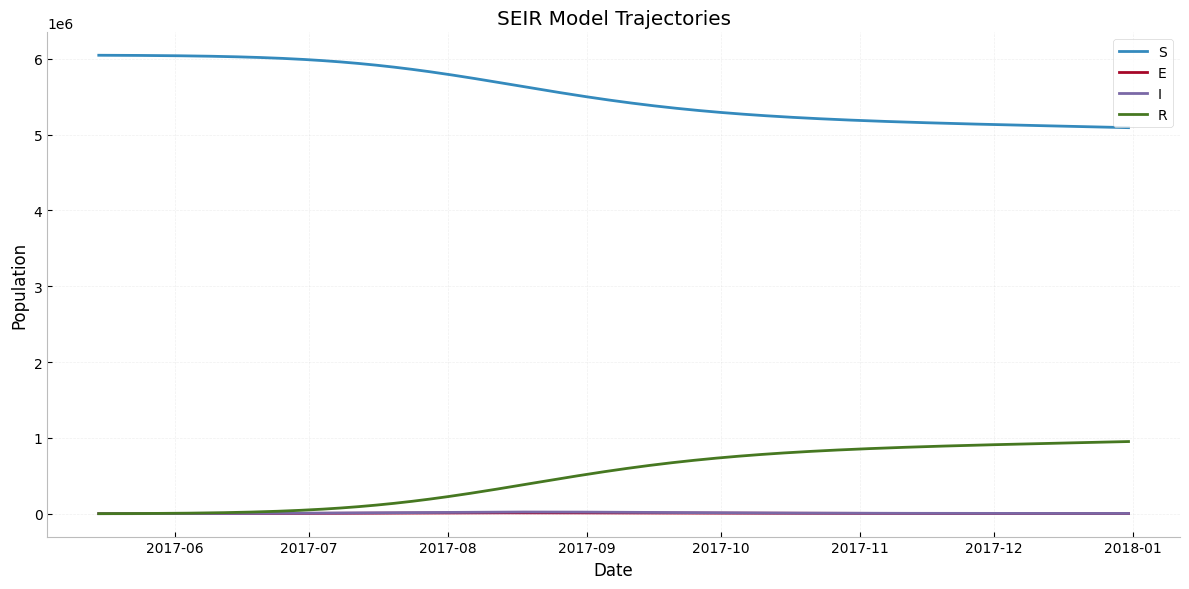

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(pred.index, pred["S"], label="S")
ax.plot(pred.index, pred["E"], label="E")
ax.plot(pred.index, pred["I"], label="I")
ax.plot(pred.index, pred["R"], label="R")

ax.set_title("SEIR Model Trajectories")
ax.set_xlabel("Date")
ax.set_ylabel("Population")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()